# Laboratorio 4 - Análisis de datos geoespaciales

**Avance: ejercicios 1 al 4**  
**Integrantes:** Milton Polanco y Osman de León

En este avance se obtienen imágenes Sentinel-2 de los lagos Atitlán y Amatitlán, se calculan los índices solicitados y se revisa el cambio del indicador de cianobacteria entre fechas.

## Configuración

Las coordenadas, fechas, nubosidad y satélite se copiaron de la consigna. Se trabaja a 20 m porque la banda B05, usada en el cálculo de cianobacteria, tiene esa resolución.

In [11]:
from datetime import datetime, timezone
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.rasters import leer_bandas

CARPETA_RAW = RAIZ / "data" / "raw"
CARPETA_PROCESSED = RAIZ / "data" / "processed"
CARPETA_FIGURES = RAIZ / "figures"
for carpeta in (CARPETA_RAW, CARPETA_PROCESSED, CARPETA_FIGURES):
    carpeta.mkdir(parents=True, exist_ok=True)

ARCHIVO_RESUMEN = CARPETA_PROCESSED / "resumen_temporal.csv"
ARCHIVO_CRITICAS = CARPETA_PROCESSED / "fechas_criticas.csv"
ARCHIVO_CATALOGO = CARPETA_RAW / "catalogo_escenas.json"
ARCHIVO_FIGURA = CARPETA_FIGURES / "evolucion_temporal_cianobacteria.png"

URL_OPENEO = "https://openeosh.dataspace.copernicus.eu"
URL_STAC = "https://earth-search.aws.element84.com/v1/search"
COLECCION_STAC = "sentinel-2-l2a"

LAGOS = {
    "Amatitlán": {
        "west": -90.638065,
        "east": -90.512924,
        "south": 14.412347,
        "north": 14.493799,
    },
    "Atitlán": {
        "west": -91.326256,
        "east": -91.071510,
        "south": 14.594800,
        "north": 14.750979,
    },
}

FECHAS = pd.DataFrame([
    ("Amatitlán", "2025-01-28", 0.06, "Sentinel-2B"),
    ("Amatitlán", "2025-04-15", 0.09, "Sentinel-2A"),
    ("Amatitlán", "2025-04-28", 1.03, "Sentinel-2B"),
    ("Amatitlán", "2025-11-24", 0.50, "Sentinel-2B"),
    ("Amatitlán", "2026-01-08", 0.77, "Sentinel-2C"),
    ("Amatitlán", "2026-02-02", 0.39, "Sentinel-2B"),
    ("Amatitlán", "2026-02-07", 0.02, "Sentinel-2C"),
    ("Amatitlán", "2026-03-29", 0.01, "Sentinel-2C"),
    ("Amatitlán", "2026-04-13", 0.09, "Sentinel-2B"),
    ("Amatitlán", "2026-04-28", 4.96, "Sentinel-2C"),
    ("Amatitlán", "2026-06-19", 13.00, "Sentinel-2A"),
    ("Atitlán", "2025-01-18", 0.02, "Sentinel-2B"),
    ("Atitlán", "2025-04-13", 0.54, "Sentinel-2C"),
    ("Atitlán", "2025-05-13", 4.37, "Sentinel-2C"),
    ("Atitlán", "2025-07-17", 3.57, "Sentinel-2A"),
    ("Atitlán", "2025-11-21", 3.15, "Sentinel-2A"),
    ("Atitlán", "2025-12-29", 3.17, "Sentinel-2C"),
    ("Atitlán", "2026-02-12", 0.04, "Sentinel-2B"),
    ("Atitlán", "2026-03-24", 3.17, "Sentinel-2B"),
    ("Atitlán", "2026-04-13", 0.01, "Sentinel-2B"),
    ("Atitlán", "2026-04-28", 4.96, "Sentinel-2C"),
    ("Atitlán", "2026-07-22", 4.02, "Sentinel-2B"),
], columns=["lago", "fecha", "nubosidad_oficial_pct", "satelite"])

FECHAS["fecha"] = pd.to_datetime(FECHAS["fecha"])
pd.set_option("display.max_columns", 20)

# 1. Conexión con la API de Sentinel-2

Se consulta la API openEO de Copernicus Data Space para comprobar que la colección `SENTINEL2_L2A` y las bandas necesarias están disponibles. Esta consulta de metadatos no requiere iniciar sesión.

In [12]:
versiones = requests.get(f"{URL_OPENEO}/.well-known/openeo", timeout=30)
versiones.raise_for_status()
url_api = versiones.json()["versions"][-1]["url"].rstrip("/")

respuesta_coleccion = requests.get(
    f"{url_api}/collections/SENTINEL2_L2A", timeout=30
)
respuesta_coleccion.raise_for_status()
metadatos_coleccion = respuesta_coleccion.json()
bandas_disponibles = metadatos_coleccion["cube:dimensions"]["bands"]["values"]
bandas_necesarias = ["B02", "B03", "B04", "B05", "B08", "B11", "B12"]

pd.Series({
    "api": "Copernicus Data Space openEO",
    "coleccion": metadatos_coleccion["id"],
    "bandas disponibles": all(b in bandas_disponibles for b in bandas_necesarias),
})

api                   Copernicus Data Space openEO
coleccion                            SENTINEL2_L2A
bandas disponibles                            True
dtype: object

La respuesta confirma que la colección puede usarse. El procesamiento directo en openEO pide autenticación OIDC, así que las imágenes se leen desde el catálogo público STAC de Earth Search, que distribuye el mismo producto Sentinel-2 L2A como COG. No se guardan credenciales en el proyecto.

# 2. Obtención de los datos raster

Cada fecha se busca por separado. De cada archivo se lee solo el rectángulo del lago y, cuando el área cruza dos teselas, se completa el mosaico con ambas. Las escenas completas no se guardan en el repositorio.

In [13]:
def buscar_escenas(bbox, fecha, nubosidad, satelite):
    respuesta = requests.post(
        URL_STAC,
        json={
            "collections": [COLECCION_STAC],
            "bbox": [bbox["west"], bbox["south"], bbox["east"], bbox["north"]],
            "datetime": f"{fecha}T00:00:00Z/{fecha}T23:59:59Z",
            "limit": 20,
        },
        timeout=45,
    )
    respuesta.raise_for_status()

    escenas = [
        escena for escena in respuesta.json().get("features", [])
        if escena["properties"].get("platform", "").lower() == satelite.lower()
    ]
    if not escenas:
        raise LookupError(f"No se encontró {satelite} para {fecha}.")

    # La nubosidad de la consigna ayuda a ordenar las teselas del mismo día.
    escenas.sort(key=lambda escena: abs(
        float(escena["properties"].get("eo:cloud_cover", 100)) - nubosidad
    ))
    return escenas

In [14]:
FECHAS

,lago,fecha,nubosidad_oficial_pct,satelite
0,Amatitlán,2025-01-28,0.06,Sentinel-2B
1,Amatitlán,2025-04-15,0.09,Sentinel-2A
2,Amatitlán,2025-04-28,1.03,Sentinel-2B
3,Amatitlán,2025-11-24,0.50,Sentinel-2B
4,Amatitlán,2026-01-08,0.77,Sentinel-2C
5,Amatitlán,2026-02-02,0.39,Sentinel-2B
6,Amatitlán,2026-02-07,0.02,Sentinel-2C
7,Amatitlán,2026-03-29,0.01,Sentinel-2C
8,Amatitlán,2026-04-13,0.09,Sentinel-2B
9,Amatitlán,2026-04-28,4.96,Sentinel-2C


# 3. Cálculo de NDVI, NDWI y cianobacteria

Se usaron las siguientes expresiones:

- $NDVI=(B08-B04)/(B08+B04)$
- $NDWI=(B03-B08)/(B03+B08)$
- $NDCI=(B05-B04)/(B05+B04)$

El valor de clorofila-a se obtiene con el polinomio del script **CyanoLakes Chlorophyll-a NDCI** de Sentinel Hub: $826.57NDCI^3-176.43NDCI^2+19NDCI+4.071$. También se reproduce su máscara de agua y se usa la banda SCL para excluir nubes, sombras y píxeles sin datos.

In [15]:
def division_segura(numerador, denominador):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.divide(
            numerador,
            denominador,
            out=np.full_like(numerador, np.nan, dtype="float32"),
            where=np.abs(denominador) > 1e-8,
        )


def calcular_indices(bandas):
    azul = bandas["B02"]
    verde = bandas["B03"]
    rojo = bandas["B04"]
    borde_rojo = bandas["B05"]
    nir = bandas["B08"]
    swir1 = bandas["B11"]
    swir2 = bandas["B12"]
    scl = bandas["SCL"].astype("int16")

    ndvi = division_segura(nir - rojo, nir + rojo)
    ndwi = division_segura(verde - nir, verde + nir)
    mndwi = division_segura(verde - swir1, verde + swir1)
    ndwi_hojas = division_segura(nir - swir1, nir + swir1)
    awei_sombra = azul + 2.5 * verde - 1.5 * (nir + swir1) - 0.25 * swir2
    awei_sin_sombra = 4 * (verde - swir1) - (0.25 * nir + 2.75 * swir1)
    dbsi = division_segura(swir1 - verde, swir1 + verde) - ndvi

    agua = (
        (mndwi > 0.42)
        | (ndwi > 0.40)
        | (awei_sin_sombra > 0.1879)
        | (awei_sombra > 0.1112)
        | (ndvi < -0.20)
        | (ndwi_hojas > 1)
    )
    agua &= ~((awei_sin_sombra <= -0.03) | (dbsi > 0))

    # SCL: 3 es sombra; 8, 9 y 10 son nubes; 11 es nieve o hielo.
    cielo_valido = ~np.isin(scl, [0, 3, 8, 9, 10, 11])
    datos_disponibles = np.all(
        np.stack([bandas[nombre] > 0 for nombre in bandas if nombre != "SCL"]),
        axis=0,
    )
    pixeles_validos = agua & cielo_valido & datos_disponibles

    ndci = division_segura(borde_rojo - rojo, borde_rojo + rojo)
    cianobacteria = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    rango_valido = pixeles_validos & (cianobacteria >= 0) & (cianobacteria <= 500)

    return {
        "ndvi": np.where(pixeles_validos, ndvi, np.nan),
        "ndwi": np.where(pixeles_validos, ndwi, np.nan),
        "cianobacteria": np.where(rango_valido, cianobacteria, np.nan),
        "pixeles_validos": pixeles_validos,
        "datos_disponibles": datos_disponibles,
    }

In [16]:
def promedio_valido(arreglo):
    valores = arreglo[np.isfinite(arreglo)]
    return float(valores.mean()) if valores.size else np.nan


def procesar_observacion(fila):
    lago = fila["lago"]
    fecha = fila["fecha"].strftime("%Y-%m-%d")
    bbox = LAGOS[lago]
    escenas = buscar_escenas(
        bbox, fecha, fila["nubosidad_oficial_pct"], fila["satelite"]
    )
    bandas = leer_bandas(escenas, bbox)
    indices = calcular_indices(bandas)
    principal = escenas[0]

    disponibles = int(indices["datos_disponibles"].sum())
    total = indices["datos_disponibles"].size
    resultado = {
        "lago": lago,
        "fecha": fecha,
        "satelite": fila["satelite"],
        "nubosidad_oficial_pct": fila["nubosidad_oficial_pct"],
        "nubosidad_catalogo_pct": principal["properties"].get("eo:cloud_cover", np.nan),
        "cobertura_bbox_pct": 100 * disponibles / total,
        "pixeles_agua_validos": int(indices["pixeles_validos"].sum()),
        "cianobacteria_promedio": promedio_valido(indices["cianobacteria"]),
        "ndvi_promedio": promedio_valido(indices["ndvi"]),
        "ndwi_promedio": promedio_valido(indices["ndwi"]),
        "item_principal": principal["id"],
    }

    registro = {
        "lake": lago,
        "date": fecha,
        "official_cloud_cover": fila["nubosidad_oficial_pct"],
        "satellite": fila["satelite"],
        "items": [
            {
                "id": escena["id"],
                "datetime": escena["properties"].get("datetime"),
                "cloud_cover": escena["properties"].get("eo:cloud_cover"),
            }
            for escena in escenas
        ],
    }
    return resultado, registro

In [17]:
VOLVER_A_DESCARGAR = False

if ARCHIVO_RESUMEN.exists() and not VOLVER_A_DESCARGAR:
    resumen = pd.read_csv(ARCHIVO_RESUMEN, parse_dates=["fecha"])
    print("Se usó el resumen guardado. Cambie VOLVER_A_DESCARGAR a True para repetir la consulta.")
else:
    resultados = []
    catalogo = []

    for numero, fila in FECHAS.iterrows():
        fecha_texto = fila["fecha"].strftime("%Y-%m-%d")
        print(f"[{numero + 1:02d}/{len(FECHAS)}] {fila['lago']} - {fecha_texto}")

        try:
            resultado, registro = procesar_observacion(fila)
        except LookupError as error:
            print(f"  Aviso: {error}")
            resultado = {
                "lago": fila["lago"],
                "fecha": fecha_texto,
                "satelite": fila["satelite"],
                "nubosidad_oficial_pct": fila["nubosidad_oficial_pct"],
                "nubosidad_catalogo_pct": np.nan,
                "cobertura_bbox_pct": 0.0,
                "pixeles_agua_validos": 0,
                "cianobacteria_promedio": np.nan,
                "ndvi_promedio": np.nan,
                "ndwi_promedio": np.nan,
                "item_principal": "SIN_ESCENA_EN_CATALOGO",
            }
            registro = {
                "lake": fila["lago"],
                "date": fecha_texto,
                "satellite": fila["satelite"],
                "items": [],
                "warning": str(error),
            }

        resultados.append(resultado)
        catalogo.append(registro)

    resumen = pd.DataFrame(resultados)
    resumen["fecha"] = pd.to_datetime(resumen["fecha"])
    resumen = resumen.sort_values(["lago", "fecha"]).reset_index(drop=True)
    resumen.to_csv(ARCHIVO_RESUMEN, index=False, encoding="utf-8-sig")

    contenido_catalogo = {
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "source": URL_STAC,
        "collection": COLECCION_STAC,
        "records": catalogo,
    }
    ARCHIVO_CATALOGO.write_text(
        json.dumps(contenido_catalogo, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

Se usó el resumen guardado. Cambie VOLVER_A_DESCARGAR a True para repetir la consulta.


In [18]:
columnas = [
    "lago", "fecha", "satelite", "nubosidad_oficial_pct",
    "cobertura_bbox_pct", "pixeles_agua_validos",
    "cianobacteria_promedio", "ndvi_promedio", "ndwi_promedio",
]
resumen[columnas].round(3)

C:\Users\mdax8\AppData\Local\Temp\ipykernel_22584\1319194963.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  resumen[columnas].round(3)


,lago,fecha,satelite,nubosidad_oficial_pct,cobertura_bbox_pct,pixeles_agua_validos,cianobacteria_promedio,ndvi_promedio,ndwi_promedio
0,Amatitlán,2025-01-28,Sentinel-2B,0.06,99.999,27596,14.355,-0.347,0.586
1,Amatitlán,2025-04-15,Sentinel-2A,0.09,100.000,11583,10.343,-0.111,0.335
2,Amatitlán,2025-04-28,Sentinel-2B,1.03,100.000,22780,13.521,-0.085,0.333
3,Amatitlán,2025-11-24,Sentinel-2B,0.50,100.000,29854,13.181,-0.351,0.513
4,Amatitlán,2026-01-08,Sentinel-2C,0.77,100.000,30925,23.067,-0.087,0.365
5,Amatitlán,2026-02-02,Sentinel-2B,0.39,100.000,2611,6.490,-0.205,0.356
6,Amatitlán,2026-02-07,Sentinel-2C,0.02,100.000,9064,7.837,-0.220,0.433
7,Amatitlán,2026-03-29,Sentinel-2C,0.01,100.000,22171,17.150,-0.063,0.320
8,Amatitlán,2026-04-13,Sentinel-2B,0.09,100.000,34280,16.418,-0.029,0.287
9,Amatitlán,2026-04-28,Sentinel-2C,4.96,0.000,0,NaN,NaN,NaN


El promedio se calcula únicamente con los píxeles de agua que pasaron la máscara de calidad. Las dos fechas sin escena se mantienen en la tabla como datos faltantes porque la consigna pide trabajar solo con las fechas indicadas.

# 4. Análisis temporal

La consigna no establece un límite sanitario para definir una floración. Para este avance se toma el valor promedio más alto de cada lago como su fecha crítica y se compara con el resto de la serie.

In [19]:
fechas_criticas = (
    resumen.dropna(subset=["cianobacteria_promedio"])
    .sort_values("cianobacteria_promedio", ascending=False)
    .groupby("lago", as_index=False)
    .first()
    .sort_values("lago")
)
fechas_criticas.to_csv(ARCHIVO_CRITICAS, index=False, encoding="utf-8-sig")

fechas_criticas[["lago", "fecha", "cianobacteria_promedio"]].round(2)

C:\Users\mdax8\AppData\Local\Temp\ipykernel_22584\3957595481.py:10: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  fechas_criticas[["lago", "fecha", "cianobacteria_promedio"]].round(2)


,lago,fecha,cianobacteria_promedio
0,Amatitlán,2026-06-19,67.49
1,Atitlán,2025-01-18,9.93


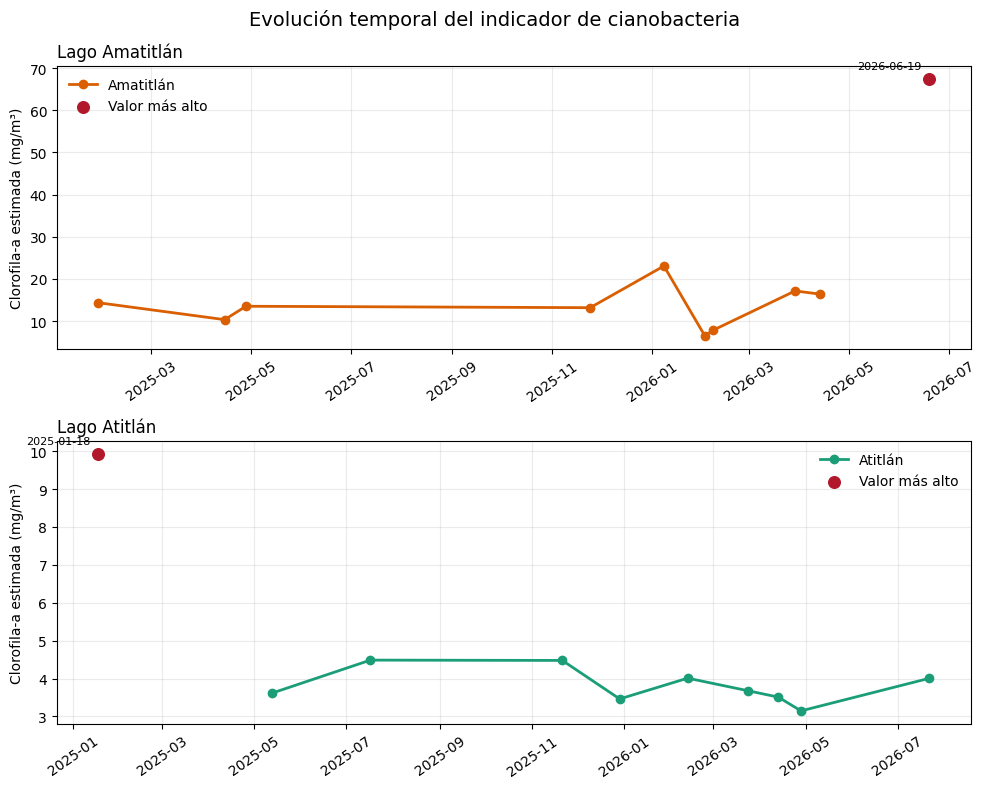

In [20]:
colores = {"Amatitlán": "#d95f02", "Atitlán": "#1b9e77"}
fig, ejes = plt.subplots(2, 1, figsize=(10, 8))

for eje, (lago, datos) in zip(ejes, resumen.groupby("lago", sort=False)):
    datos = datos.sort_values("fecha")
    eje.plot(
        datos["fecha"],
        datos["cianobacteria_promedio"],
        color=colores[lago],
        marker="o",
        linewidth=2,
        label=lago,
    )

    critica = fechas_criticas[fechas_criticas["lago"] == lago].iloc[0]
    eje.scatter(
        critica["fecha"],
        critica["cianobacteria_promedio"],
        color="#b2182b",
        s=70,
        zorder=3,
        label="Valor más alto",
    )
    eje.annotate(
        critica["fecha"].strftime("%Y-%m-%d"),
        (critica["fecha"], critica["cianobacteria_promedio"]),
        xytext=(-6, 7),
        textcoords="offset points",
        ha="right",
        fontsize=8,
    )

    eje.set_title(f"Lago {lago}", loc="left")
    eje.set_ylabel("Clorofila-a estimada (mg/m³)")
    eje.grid(alpha=0.25)
    eje.legend(frameon=False)
    eje.tick_params(axis="x", rotation=35)

fig.suptitle("Evolución temporal del indicador de cianobacteria", fontsize=14)
fig.tight_layout()
fig.savefig(ARCHIVO_FIGURA, dpi=180, bbox_inches="tight")
plt.show()

## Interpretación inicial

En Amatitlán los valores cambian bastante entre fechas. El menor promedio aparece el 2 de febrero de 2026 y el mayor el 19 de junio de 2026, cuando llega a 67.49 mg/m³. Como esa última imagen también tiene la nubosidad más alta de la serie, el resultado se debe revisar con cuidado en el análisis espacial.

Atitlán tiene su valor más alto el 18 de enero de 2025, con 9.93 mg/m³. Desde mayo de 2025 los promedios quedan entre 3.14 y 4.49 mg/m³, por lo que no se observa un aumento continuo durante el período.

La lluvia, la temperatura, la mezcla del agua y la entrada de nutrientes podrían influir en estos cambios. En este avance todavía no se comparan esas variables, así que no se puede asignar una causa solo con las imágenes. El indicador tampoco confirma toxicidad; para eso harían falta mediciones de campo.